# 🛡️ NetSentinel — App Fingerprinting from Encrypted Traffic
## Training Notebook

**Goal:** Identify which app (Netflix, YouTube, Instagram, etc.) generated network traffic using only packet metadata — without decrypting anything.

**Approach:** Inspired by PACKETPRINT (NDSS 2022), we use packet size sequences, inter-arrival times, burst patterns, and flow statistics to fingerprint apps.

**Models:** XGBoost + 1D-CNN

---

## 1. Setup

In [23]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, classification_report
devices = tf.config.list_physical_devices('GPU')
if devices:
    print(f"Metal GPU Detected: {devices[0]}")
    # Perform a quick operation to trigger the Metal kernels
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
    print("Test Matrix Multiplication Success:", tf.matmul(a, b))
else:
    print("GPU NOT FOUND. Defaulting to CPU.")

Metal GPU Detected: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Test Matrix Multiplication Success: tf.Tensor(
[[1. 3.]
 [3. 7.]], shape=(2, 2), dtype=float32)


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import glob
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Dense, Dropout,
    Flatten, BatchNormalization, Input, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('All libraries loaded ✅')
print(f'TensorFlow: {tf.__version__}')

All libraries loaded ✅
TensorFlow: 2.15.0


## 2. Load Dataset

Our dataset was collected using NetSentinel's traffic collector. Each CSV contains sliding-window samples (5s windows, 2s step) from a single app session. Features include packet size statistics, inter-arrival times, burst patterns, direction ratios, and raw packet size sequences (PSS).

In [3]:
# Load all CSVs from the app_traffic directory
# Update this path to where your CSV files are
DATA_DIR = 'data/app_traffic'  # Change if needed

csv_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
print(f'Found {len(csv_files)} CSV files:\n')

dfs = []
for f in sorted(csv_files):
    df = pd.read_csv(f)
    app = os.path.basename(f).split('_')[0]
    df['app'] = app  # Ensure label is set from filename
    dfs.append(df)
    print(f'  {os.path.basename(f)}: {len(df)} samples (app: {app})')

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {len(df)} samples across {df["app"].nunique()} apps')

Found 6 CSV files:

  chrome_browsing_20260328_223424.csv: 198 samples (app: chrome)
  facebook_20260328_220955.csv: 198 samples (app: facebook)
  gmail_20260328_222708.csv: 198 samples (app: gmail)
  instagram_20260328_221614.csv: 199 samples (app: instagram)
  netflix_20260328_215513.csv: 198 samples (app: netflix)
  youtube_20260328_220333.csv: 197 samples (app: youtube)

Total: 1188 samples across 6 apps


In [4]:
# Class distribution
print('=== Class Distribution ===')
print(df['app'].value_counts())

fig = px.bar(x=df['app'].value_counts().index, 
             y=df['app'].value_counts().values,
             title='Samples per App',
             labels={'x': 'App', 'y': 'Samples'},
             color=df['app'].value_counts().index,
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(height=400, showlegend=False)
fig.show()

=== Class Distribution ===
app
instagram    199
chrome       198
facebook     198
gmail        198
netflix      198
youtube      197
Name: count, dtype: int64


## 3. Exploratory Data Analysis

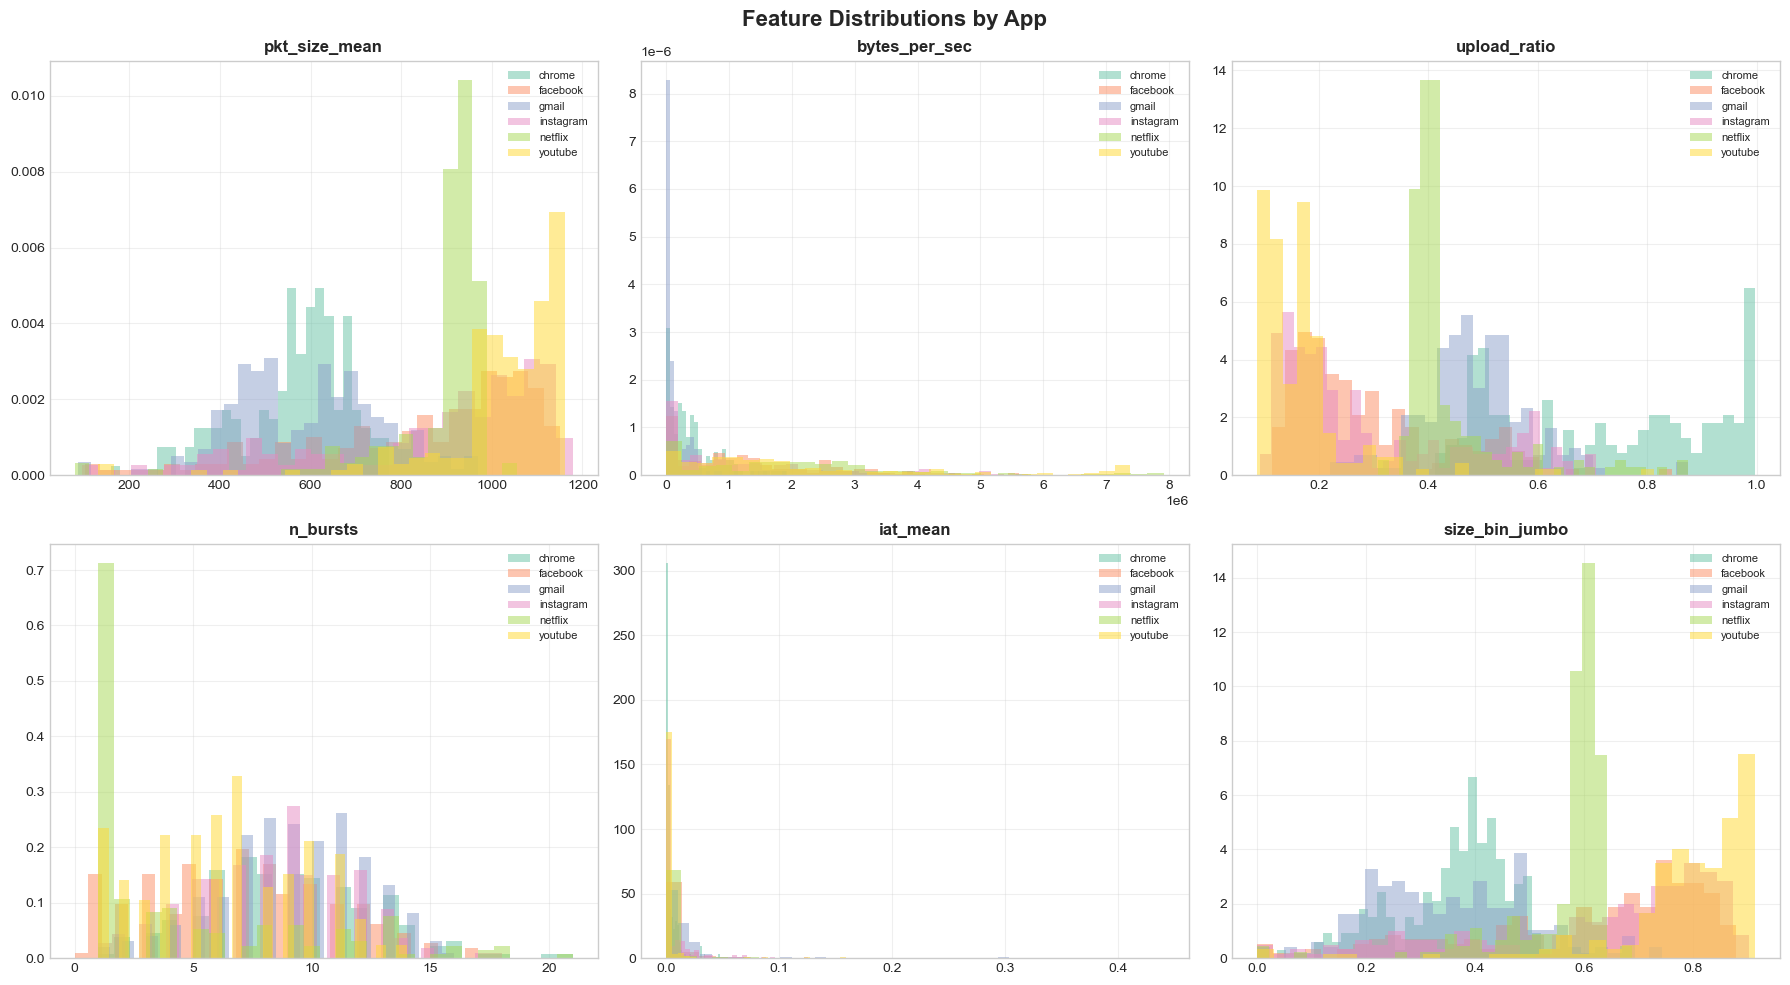

In [5]:
# 3.1 — Key feature distributions per app
key_features = ['pkt_size_mean', 'bytes_per_sec', 'upload_ratio', 
                'n_bursts', 'iat_mean', 'size_bin_jumbo']

# Only plot features that exist
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feat in enumerate(key_features):
    ax = axes[i//3][i%3]
    for app in df['app'].unique():
        subset = df[df['app'] == app][feat]
        ax.hist(subset, bins=30, alpha=0.5, label=app, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by App', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('app_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 3.2 — QUIC ratio per app (great discriminator)
if 'quic_ratio' in df.columns:
    fig = px.box(df, x='app', y='quic_ratio', color='app',
                 title='QUIC Protocol Usage by App',
                 labels={'quic_ratio': 'QUIC Ratio', 'app': 'App'})
    fig.update_layout(height=400, showlegend=False)
    fig.show()

In [7]:
# 3.3 — Upload vs Download ratio scatter
fig = px.scatter(df, x='upload_ratio', y='bytes_per_sec', color='app',
                 title='Upload Ratio vs Bandwidth by App',
                 labels={'upload_ratio': 'Upload Ratio', 'bytes_per_sec': 'Bytes/sec'},
                 opacity=0.6)
fig.update_layout(height=500)
fig.show()

In [8]:
# 3.4 — App traffic fingerprint radar chart
radar_features = ['pkt_size_mean', 'bytes_per_sec', 'upload_ratio',
                  'n_bursts', 'iat_mean', 'size_bin_jumbo']
radar_features = [f for f in radar_features if f in df.columns]

fig = go.Figure()
for app in df['app'].unique():
    subset = df[df['app'] == app][radar_features].mean()
    # Normalize to 0-1 for radar
    normalized = (subset - df[radar_features].min()) / (df[radar_features].max() - df[radar_features].min() + 1e-8)
    fig.add_trace(go.Scatterpolar(
        r=normalized.values.tolist() + [normalized.values[0]],
        theta=radar_features + [radar_features[0]],
        name=app, fill='toself', opacity=0.6
    ))
fig.update_layout(title='App Traffic Fingerprint Profiles', height=500,
                  polar=dict(radialaxis=dict(visible=True, range=[0, 1])))
fig.show()

## 4. Feature Preparation

In [9]:
# 4.1 — Encode labels
le = LabelEncoder()
y = le.fit_transform(df['app'])
app_names = le.classes_
n_classes = len(app_names)

print(f'Classes ({n_classes}): {list(app_names)}')
print(f'Label mapping: {dict(zip(app_names, range(n_classes)))}')

Classes (6): ['chrome', 'facebook', 'gmail', 'instagram', 'netflix', 'youtube']
Label mapping: {'chrome': 0, 'facebook': 1, 'gmail': 2, 'instagram': 3, 'netflix': 4, 'youtube': 5}


In [10]:
# 4.2 — Statistical features (for XGBoost)
stat_features = [
    'window_duration', 'total_packets', 'total_bytes',
    'packets_per_sec', 'bytes_per_sec',
    'pkt_size_mean', 'pkt_size_std', 'pkt_size_min', 'pkt_size_max',
    'pkt_size_median', 'pkt_size_q25', 'pkt_size_q75', 'pkt_size_skew', 'pkt_size_iqr',
    'size_bin_tiny', 'size_bin_small', 'size_bin_medium', 'size_bin_large', 'size_bin_jumbo',
    'payload_mean', 'payload_std', 'payload_max', 'payload_zero_ratio', 'payload_total',
    'iat_mean', 'iat_std', 'iat_min', 'iat_max', 'iat_median', 'iat_q25', 'iat_q75',
    'upload_packets', 'download_packets', 'upload_ratio', 'download_ratio', 'up_down_ratio',
    'up_bytes_total', 'up_size_mean', 'up_size_std', 'up_size_max',
    'down_bytes_total', 'down_size_mean', 'down_size_std', 'down_size_max',
    'up_iat_mean', 'up_iat_std', 'down_iat_mean', 'down_iat_std',
    'n_bursts', 'avg_burst_size', 'max_burst_size', 'burst_ratio',
    'n_unique_dst_ports', 'tcp_ratio', 'udp_ratio',
]

# Add quic_ratio if available
if 'quic_ratio' in df.columns:
    stat_features.append('quic_ratio')

available_stat = [f for f in stat_features if f in df.columns]
X_stat = df[available_stat].fillna(0).replace([np.inf, -np.inf], 0)

scaler = StandardScaler()
X_stat_scaled = pd.DataFrame(scaler.fit_transform(X_stat), columns=X_stat.columns)

print(f'Statistical features: {len(available_stat)}')

Statistical features: 56


In [11]:
# 4.3 — Packet Size Sequences (for 1D-CNN)
PSS_LENGTH = 50
pss_cols = [f'pss_{i}' for i in range(PSS_LENGTH)]
available_pss = [c for c in pss_cols if c in df.columns]

X_pss = df[available_pss].fillna(0).values
pss_max = np.max(np.abs(X_pss)) + 1e-8
X_pss_norm = X_pss / pss_max

print(f'PSS features: {len(available_pss)} (sequence length)')
print(f'PSS max value: {pss_max:.0f}')

PSS features: 50 (sequence length)
PSS max value: 1514


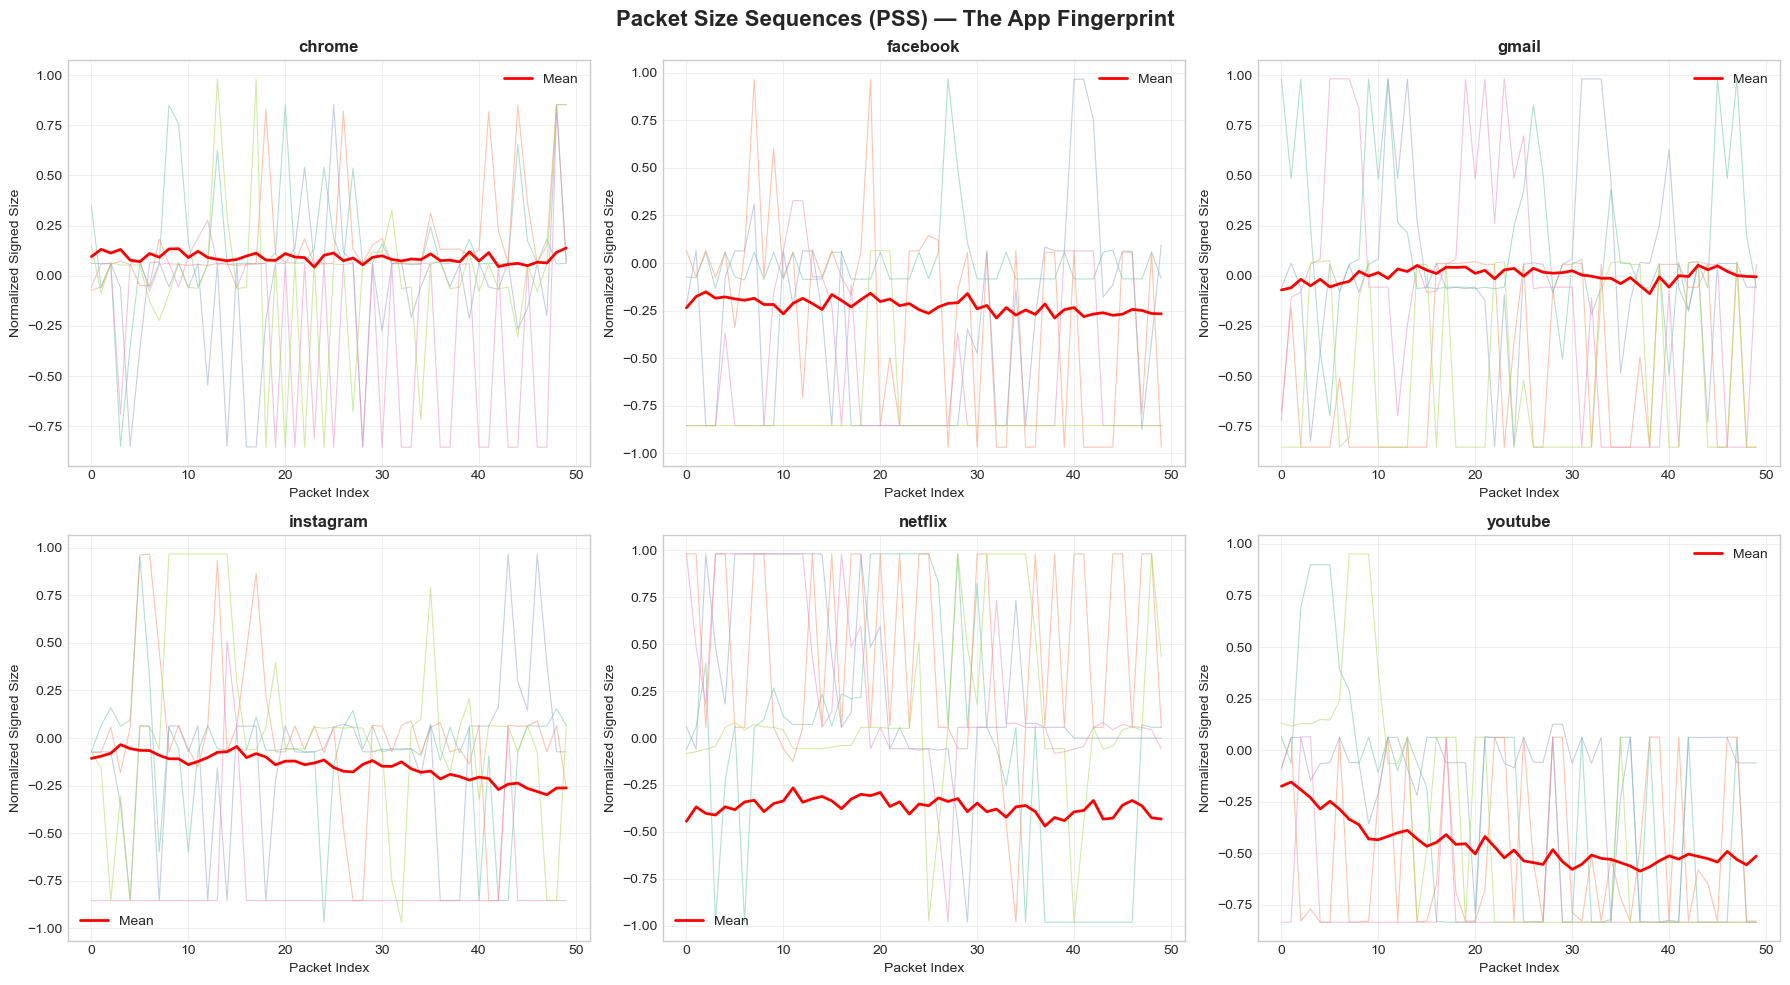

In [12]:
# 4.4 — Visualize PSS patterns per app
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, app in enumerate(app_names):
    ax = axes[idx//3][idx%3]
    app_mask = y == idx
    # Plot first 5 samples
    for i in range(min(5, app_mask.sum())):
        sample_idx = np.where(app_mask)[0][i]
        ax.plot(X_pss_norm[sample_idx], alpha=0.5, linewidth=0.8)
    # Plot mean
    ax.plot(X_pss_norm[app_mask].mean(axis=0), color='red', linewidth=2, label='Mean')
    ax.set_title(f'{app}', fontweight='bold')
    ax.set_xlabel('Packet Index')
    ax.set_ylabel('Normalized Signed Size')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide empty subplots if less than 6 apps
for idx in range(len(app_names), 6):
    axes[idx//3][idx%3].set_visible(False)

plt.suptitle('Packet Size Sequences (PSS) — The App Fingerprint', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('app_pss_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# 4.5 — Train/Test Split
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

X_stat_train, X_stat_test = X_stat_scaled.iloc[train_idx], X_stat_scaled.iloc[test_idx]
X_pss_train, X_pss_test = X_pss_norm[train_idx], X_pss_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train: {len(train_idx)} | Test: {len(test_idx)}')
print(f'Train distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train: 950 | Test: 238
Train distribution: {0: 158, 1: 159, 2: 158, 3: 159, 4: 158, 5: 158}
Test distribution: {0: 40, 1: 39, 2: 40, 3: 40, 4: 40, 5: 39}


## 5. Model Training

### 5.1 — XGBoost (Statistical Features)

XGBoost operates on hand-crafted statistical features extracted from each traffic window: packet sizes, inter-arrival times, direction ratios, burst patterns, and protocol ratios.

In [18]:
print('🚀 Training XGBoost on Statistical Features...')
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)

xgb_model.fit(X_stat_train, y_train)
xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_stat_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')

print(f'\n  Accuracy: {xgb_acc:.4f}')
print(f'  F1-Score: {xgb_f1:.4f}')
print(f'  Time: {xgb_time:.2f}s')
print(f'\n{classification_report(y_test, xgb_pred, target_names=app_names)}')

🚀 Training XGBoost on Statistical Features...

  Accuracy: 0.9202
  F1-Score: 0.9201
  Time: 1.84s

              precision    recall  f1-score   support

      chrome       1.00      0.97      0.99        40
    facebook       0.86      0.77      0.81        39
       gmail       0.93      0.95      0.94        40
   instagram       0.80      0.88      0.83        40
     netflix       0.97      0.97      0.97        40
     youtube       0.97      0.97      0.97        39

    accuracy                           0.92       238
   macro avg       0.92      0.92      0.92       238
weighted avg       0.92      0.92      0.92       238



### 5.2 — 1D-CNN (Packet Size Sequences)

The 1D-CNN operates directly on raw packet size sequences — the core idea from PACKETPRINT. Each traffic window's first 50 packet sizes (signed: positive=upload, negative=download) form a 1D signal. The CNN learns spatial patterns in this signal that are unique to each app.

In [21]:
def augment_traffic_data(X, y, noise_level=0.02, shift_max=2):
    """
    X shape: (samples, sequence_length, 1)
    """
    # 1. Jittering: Add Gaussian noise to packet sizes
    # We use a small noise_level to keep packet sizes realistic
    noise = np.random.normal(0, noise_level * np.std(X), X.shape)
    X_jitter = X + noise
    
    # 2. Shifting: Roll the sequence horizontally
    X_shift = np.copy(X)
    for i in range(len(X_shift)):
        shift = np.random.randint(-shift_max, shift_max + 1)
        X_shift[i] = np.roll(X_shift[i], shift, axis=0)
    
    # Combine original + jittered + shifted
    X_augmented = np.vstack((X, X_jitter, X_shift))
    y_augmented = np.concatenate((y, y, y))
    
    # Shuffle the augmented set
    indices = np.arange(len(X_augmented))
    np.random.shuffle(indices)
    
    return X_augmented[indices], y_augmented[indices]

# Prepare the data
# X_pss_train was your original packet size sequence
X_train_cnn_base = X_pss_train.reshape(-1, X_pss_train.shape[1], 1)

X_train_aug, y_train_aug = augment_traffic_data(X_train_cnn_base, y_train)

print(f"📊 Original Training Set: {len(X_train_cnn_base)}")
print(f"🚀 Augmented Training Set: {len(X_train_aug)}")

📊 Original Training Set: 950
🚀 Augmented Training Set: 2850


In [24]:
import time


print('🧠 Training Optimized 1D-CNN on Augmented Packet Sequences...')
start = time.time()

# 1. Use the Augmented Data (Assumes you ran the augmentation cell)
# If you haven't run it, use X_train_cnn = X_pss_train.reshape(-1, X_pss_train.shape[1], 1)
X_train_final = X_train_aug 
y_train_final = y_train_aug

# 2. Refined Model Architecture
cnn_model = Sequential([
    Input(shape=(X_train_final.shape[1], 1)),
    
    # Block 1: Focus on local feature signatures
    Conv1D(32, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # Block 2: Higher abstraction, limited width to prevent memorization
    Conv1D(32, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    GlobalAveragePooling1D(), 
    
    # Bottleneck Layer
    Dense(32, activation='relu'),
    Dropout(0.5), # Aggressive dropout for small data
    Dense(n_classes, activation='softmax'),
])

# 3. Enhanced Learning Dynamics
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=10, 
    min_lr=0.00001,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=30,      # Reduced from 100 to prevent overfitting on noise
    restore_best_weights=True, 
    verbose=1
)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Execution
history = cnn_model.fit(
    X_train_final, y_train_final,
    epochs=200,          # 300 is overkill with augmentation and patience=30
    batch_size=16,       # Smaller batch = more stochastic noise (better for small data)
    validation_split=0.2,
    callbacks=[early_stop, lr_scheduler], # CRITICAL: Added lr_scheduler here
    verbose=1
)

cnn_time = time.time() - start

# 5. Evaluation (on clean test data)
cnn_pred = np.argmax(cnn_model.predict(X_test_cnn), axis=1)
cnn_acc = accuracy_score(y_test, cnn_pred)
cnn_f1 = f1_score(y_test, cnn_pred, average='weighted')

print(f'\n  Accuracy: {cnn_acc:.4f}')
print(f'  F1-Score: {cnn_f1:.4f}')
print(f'  Time: {cnn_time:.2f}s')
print(f'\n{classification_report(y_test, cnn_pred, target_names=app_names)}')

🧠 Training Optimized 1D-CNN on Augmented Packet Sequences...
Epoch 1/200


2026-03-28 23:13:50.184708: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


143/143 [==============================] - 5s 26ms/step - loss: 1.9709 - accuracy: 0.3154 - val_loss: 2.0531 - val_accuracy: 0.1719 - lr: 0.0010
Epoch 2/200
143/143 [==============================] - 3s 19ms/step - loss: 1.7486 - accuracy: 0.4136 - val_loss: 2.0442 - val_accuracy: 0.2579 - lr: 0.0010
Epoch 3/200
143/143 [==============================] - 3s 19ms/step - loss: 1.5881 - accuracy: 0.4680 - val_loss: 1.9692 - val_accuracy: 0.3035 - lr: 0.0010
Epoch 4/200
143/143 [==============================] - 3s 20ms/step - loss: 1.4705 - accuracy: 0.5026 - val_loss: 1.6916 - val_accuracy: 0.3351 - lr: 0.0010
Epoch 5/200
143/143 [==============================] - 3s 20ms/step - loss: 1.3958 - accuracy: 0.5219 - val_loss: 1.7068 - val_accuracy: 0.3474 - lr: 0.0010
Epoch 6/200
143/143 [==============================] - 3s 19ms/step - loss: 1.3287 - accuracy: 0.5439 - val_loss: 1.2498 - val_accuracy: 0.5439 - lr: 0.0010
Epoch 7/200
143/143 [==============================] - 3s 20ms/step - 

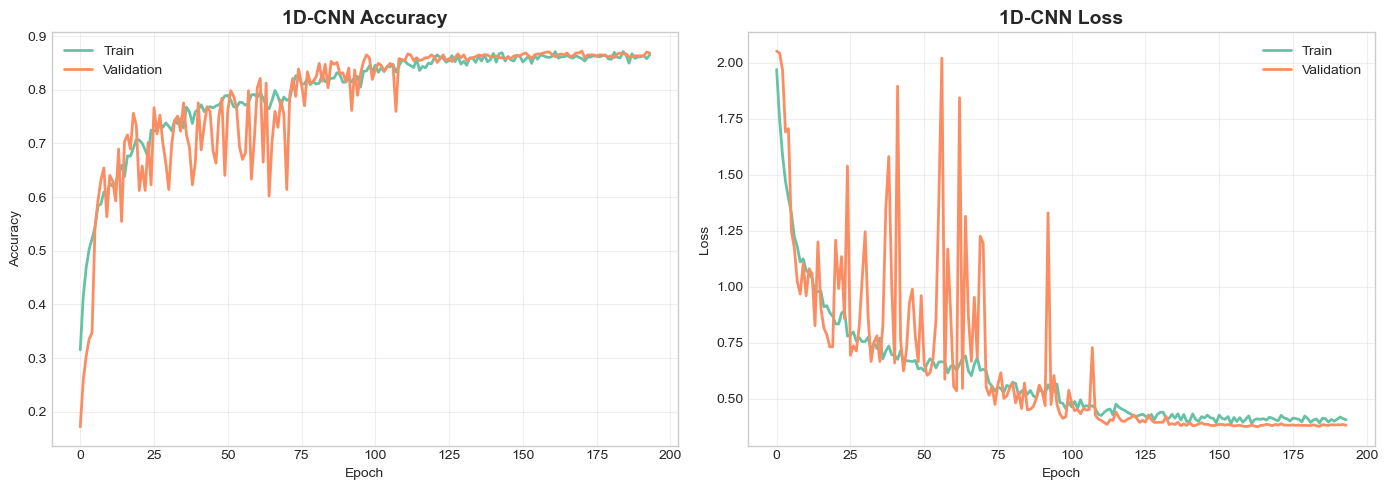

In [25]:
# CNN Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('1D-CNN Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('1D-CNN Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('app_cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Comparison

In [26]:
# 6.1 — Results Table
results_df = pd.DataFrame({
    'Model': ['XGBoost', '1D-CNN'],
    'Features': ['Statistical (hand-crafted)', 'Packet Size Sequences (raw)'],
    'Accuracy': [xgb_acc, cnn_acc],
    'F1-Score': [xgb_f1, cnn_f1],
    'Training Time': [f'{xgb_time:.1f}s', f'{cnn_time:.1f}s'],
})

print('\n' + '=' * 70)
print('📊 APP FINGERPRINTING — MODEL COMPARISON')
print('=' * 70)
print(results_df.to_string(index=False))


📊 APP FINGERPRINTING — MODEL COMPARISON
  Model                    Features  Accuracy  F1-Score Training Time
XGBoost  Statistical (hand-crafted)  0.920168  0.920082          1.8s
 1D-CNN Packet Size Sequences (raw)  0.747899  0.747616        543.9s


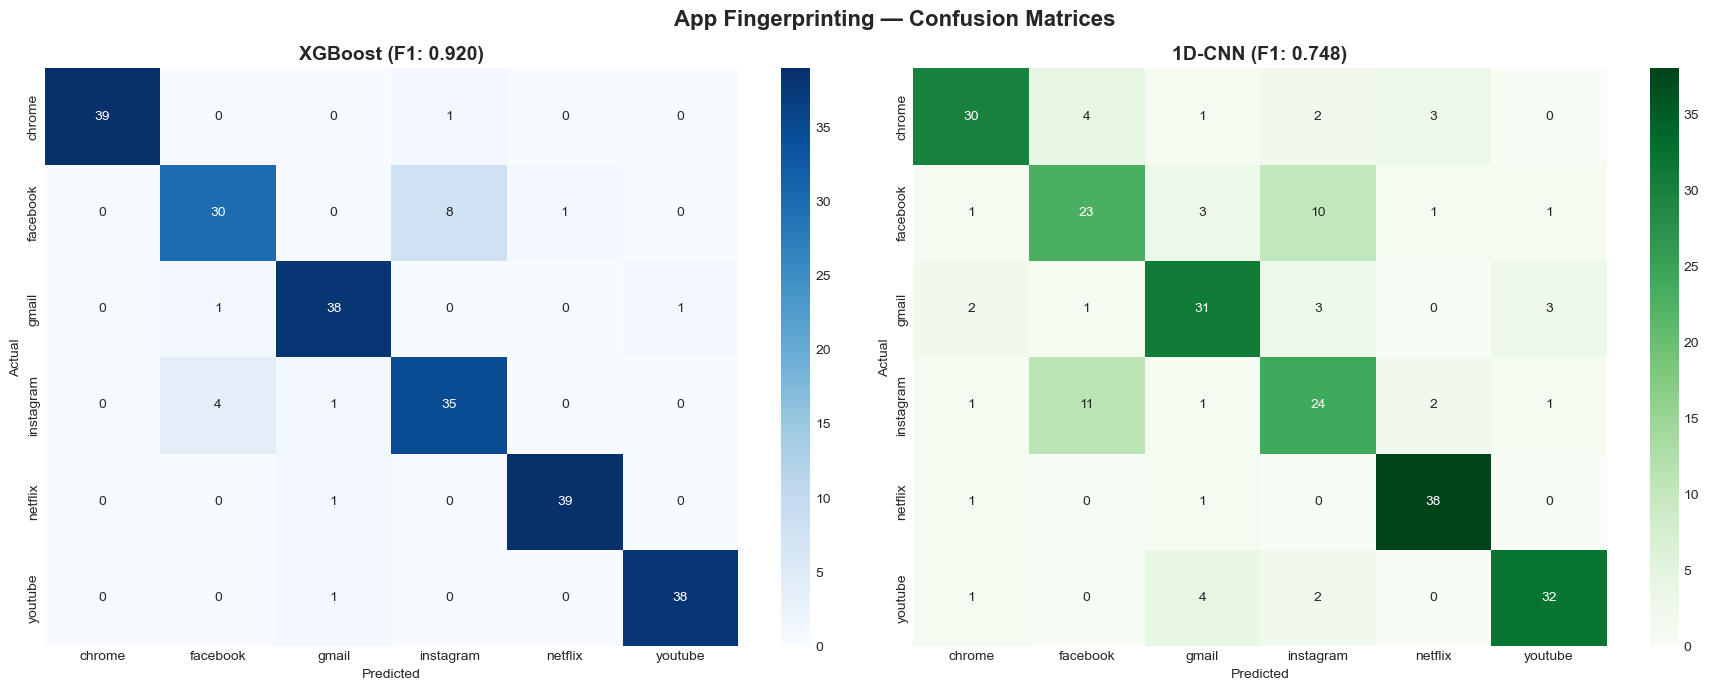

In [27]:
# 6.2 — Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=app_names, yticklabels=app_names)
axes[0].set_title(f'XGBoost (F1: {xgb_f1:.3f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_cnn = confusion_matrix(y_test, cnn_pred)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=app_names, yticklabels=app_names)
axes[1].set_title(f'1D-CNN (F1: {cnn_f1:.3f})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('App Fingerprinting — Confusion Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('app_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

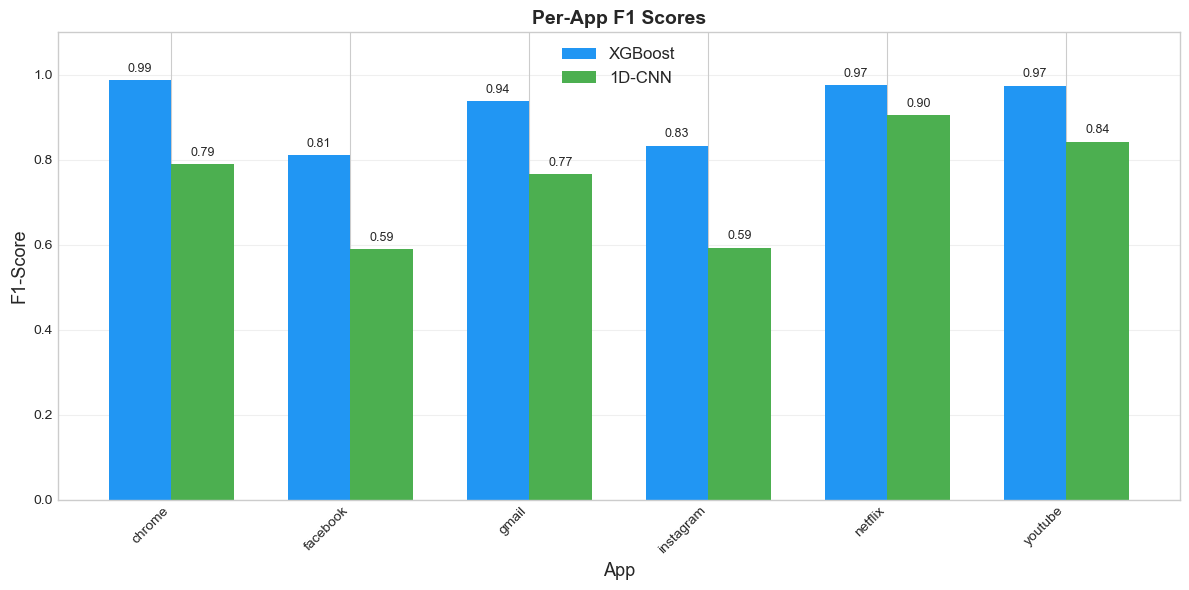

In [28]:
# 6.3 — Per-App F1 Scores
xgb_per = f1_score(y_test, xgb_pred, average=None)
cnn_per = f1_score(y_test, cnn_pred, average=None)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(n_classes)
width = 0.35

ax.bar(x - width/2, xgb_per, width, label='XGBoost', color='#2196F3')
ax.bar(x + width/2, cnn_per, width, label='1D-CNN', color='#4CAF50')

ax.set_xlabel('App', fontsize=13)
ax.set_ylabel('F1-Score', fontsize=13)
ax.set_title('Per-App F1 Scores', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(app_names, rotation=45, ha='right')
ax.legend(fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (v1, v2) in enumerate(zip(xgb_per, cnn_per)):
    ax.text(i - width/2, v1 + 0.02, f'{v1:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, v2 + 0.02, f'{v2:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('app_per_app_f1.png', dpi=150, bbox_inches='tight')
plt.show()

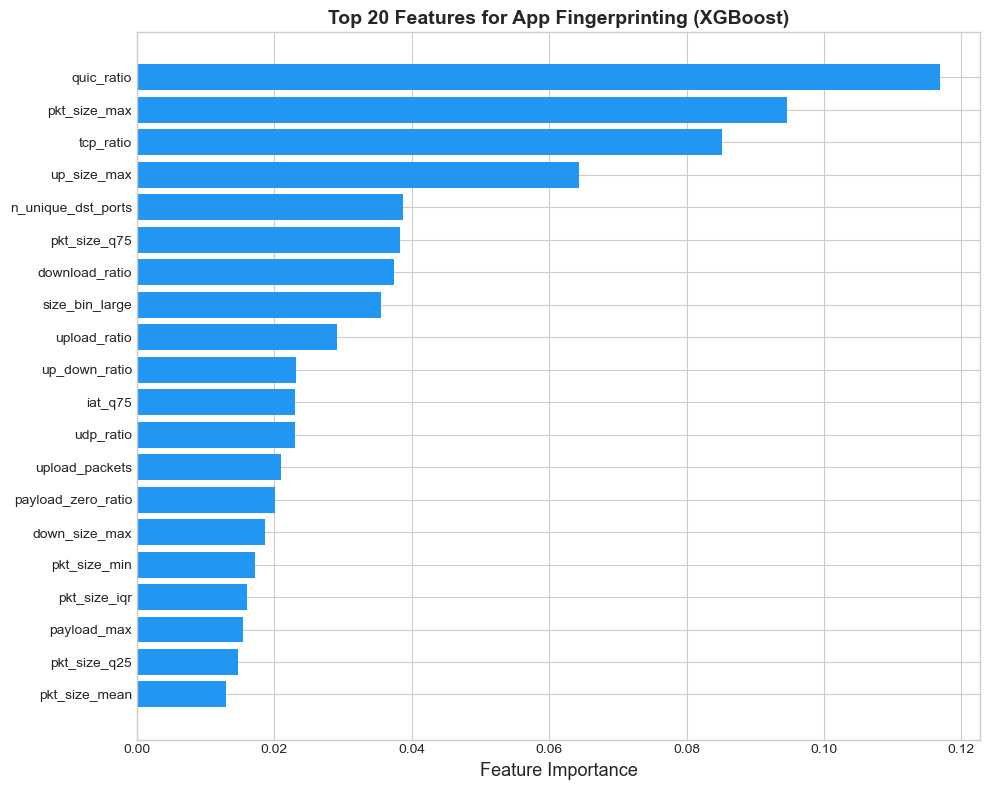

In [29]:
# 6.4 — XGBoost Feature Importance
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': available_stat,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2196F3')
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('Top 20 Features for App Fingerprinting (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('app_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cross-Validation

In [30]:
print('Running 5-Fold Cross Validation (XGBoost)...')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_stat_scaled, y), 1):
    model = XGBClassifier(n_estimators=100, max_depth=8, n_jobs=-1, 
                          random_state=42, verbosity=0, eval_metric='mlogloss',
                          use_label_encoder=False)
    model.fit(X_stat_scaled.iloc[tr_idx], y[tr_idx])
    preds = model.predict(X_stat_scaled.iloc[val_idx])
    f1 = f1_score(y[val_idx], preds, average='weighted')
    fold_scores.append(f1)
    print(f'  Fold {fold}: F1 = {f1:.4f}')

scores = np.array(fold_scores)
print(f'\n  Mean F1: {scores.mean():.4f} (+/- {scores.std()*2:.4f})')

Running 5-Fold Cross Validation (XGBoost)...
  Fold 1: F1 = 0.9116
  Fold 2: F1 = 0.8835
  Fold 3: F1 = 0.9284
  Fold 4: F1 = 0.9494
  Fold 5: F1 = 0.9117

  Mean F1: 0.9169 (+/- 0.0434)


## 8. Save Models

In [31]:
os.makedirs('models', exist_ok=True)

joblib.dump(xgb_model, 'models/app_xgboost.pkl')
joblib.dump(le, 'models/app_label_encoder.pkl')
joblib.dump(scaler, 'models/app_scaler.pkl')
joblib.dump(available_stat, 'models/app_stat_features.pkl')
joblib.dump(pss_max, 'models/app_pss_max.pkl')
cnn_model.save('models/app_cnn_model.keras')

print('All models saved ✅')
for f in os.listdir('models'):
    if f.startswith('app_'):
        size = os.path.getsize(f'models/{f}') / 1024
        print(f'  {f}: {size:.1f} KB')

All models saved ✅
  app_pss_max.pkl: 0.1 KB
  app_cnn_model.keras: 102.4 KB
  app_scaler.pkl: 3.2 KB
  app_stat_features.pkl: 0.8 KB
  app_label_encoder.pkl: 0.6 KB
  app_xgboost.pkl: 1319.1 KB


## 9. Summary

### Key Findings

1. **Apps have distinct traffic fingerprints** — even with encryption, packet size patterns, timing, and protocol choices uniquely identify applications
2. **QUIC ratio is a strong discriminator** — YouTube uses QUIC almost exclusively, while Netflix primarily uses TCP
3. **Burst patterns differ** — Messaging apps (Instagram) have more bursts than streaming apps (Netflix/YouTube)
4. **Upload/download ratio reveals app type** — Streaming is download-heavy, browsing is more balanced

### Integration with NetSentinel

The trained XGBoost model is integrated into NetSentinel's real-time dashboard. During live capture, traffic is aggregated into sliding windows, features are extracted, and the model predicts which app generated each window of traffic.

---
*NetSentinel — AI-Powered Network Traffic Analysis & App Fingerprinting*